<a href="https://colab.research.google.com/github/dandanakaka/DeepLearningLab/blob/main/DeepLearning2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install necessary libraries
!pip install scikeras scikit-learn==1.5.2

### 1. Data Loading and Preprocessing

In [ ]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
zip_file_path = '/content/archive (2).zip'
extract_dir = '/content/fashion_mnist_data'

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' extracted to '{extract_dir}'")

print(f"\nContents of '{extract_dir}':")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))

train_df = pd.read_csv(os.path.join(extract_dir, 'fashion-mnist_train.csv'))
print(f"\nTraining data shape: {train_df.shape}")
display(train_df.head())

test_df = pd.read_csv(os.path.join(extract_dir, 'fashion-mnist_test.csv'))
print(f"Test data shape: {test_df.shape}")
display(test_df.head())

'/content/archive (2).zip' extracted to '/content/fashion_mnist_data'

Contents of '/content/fashion_mnist_data':
/content/fashion_mnist_data/fashion-mnist_train.csv
/content/fashion_mnist_data/t10k-labels-idx1-ubyte
/content/fashion_mnist_data/train-images-idx3-ubyte
/content/fashion_mnist_data/train-labels-idx1-ubyte
/content/fashion_mnist_data/fashion-mnist_test.csv
/content/fashion_mnist_data/t10k-images-idx3-ubyte

Training data shape: (60000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Test data shape: (10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


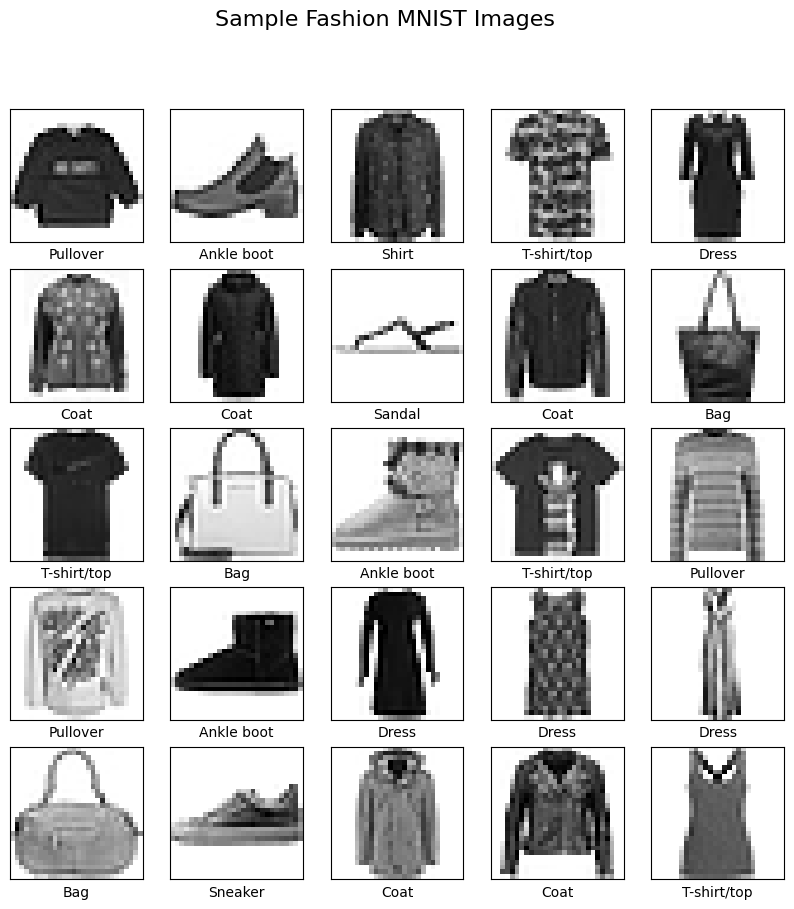

In [ ]:
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# Define class names for Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i].reshape(28, 28), cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.suptitle('Sample Fashion MNIST Images', fontsize=16)
plt.show()

In [ ]:
X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

# Determine the number of classes (0-9 for Fashion MNIST)
num_classes = len(np.unique(y_train))

y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

print("--- Data Preprocessing Summary ---")
print(f"Shape of X_train (flattened): {X_train.shape}")
print(f"Shape of X_test (flattened): {X_test.shape}")
print(f"Normalized max pixel value in X_train_normalized: {np.max(X_train_normalized)}")
print(f"Normalized min pixel value in X_train_normalized: {np.min(X_train_normalized)}")
print(f"Shape of one-hot encoded training labels: {y_train_one_hot.shape}")
print(f"Shape of one-hot encoded test labels: {y_test_one_hot.shape}")

--- Data Preprocessing Summary ---
Shape of X_train (flattened): (60000, 784)
Shape of X_test (flattened): (10000, 784)
Normalized max pixel value in X_train_normalized: 1.0
Normalized min pixel value in X_train_normalized: 0.0
Shape of one-hot encoded training labels: (60000, 10)
Shape of one-hot encoded test labels: (10000, 10)


### 2. Baseline MLP Model

In [ ]:
def create_model(n_hidden=1, n_neurons=64, activation='relu', dropout_rate=0.0, optimizer='adam'):
    model = models.Sequential()
    model.add(layers.Input(shape=(784,)))
    for _ in range(n_hidden):
        model.add(layers.Dense(n_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

baseline_model = create_model(n_hidden=2, n_neurons=128, activation='relu', optimizer='adam')
baseline_model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = baseline_model.fit(
    X_train_normalized,
    y_train_one_hot,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_normalized, y_test_one_hot)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8231 - loss: 0.4878 - val_accuracy: 0.8551 - val_loss: 0.4022
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8662 - loss: 0.3669 - val_accuracy: 0.8672 - val_loss: 0.3648
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8773 - loss: 0.3330 - val_accuracy: 0.8750 - val_loss: 0.3412
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8866 - loss: 0.3090 - val_accuracy: 0.8768 - val_loss: 0.3396
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8917 - loss: 0.2938 - val_accuracy: 0.8742 - val_loss: 0.3532
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8964 - loss: 0.2763 - val_accuracy: 0.8823 - val_loss: 0.3188
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9007 - loss: 0.2646 - val_accuracy: 0.8881 - val_loss: 0.3139
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9060 - loss: 0.2537 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Baseline Model Overall Accuracy: 89.46%

Baseline Model Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.85      0.84      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.90      0.72      0.80      1000
       Dress       0.91      0.91      0.91      1000
        Coat       0.77      0.92      0.84      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.73      0.72      0.72      1000
     Sneaker       0.93      0.96      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



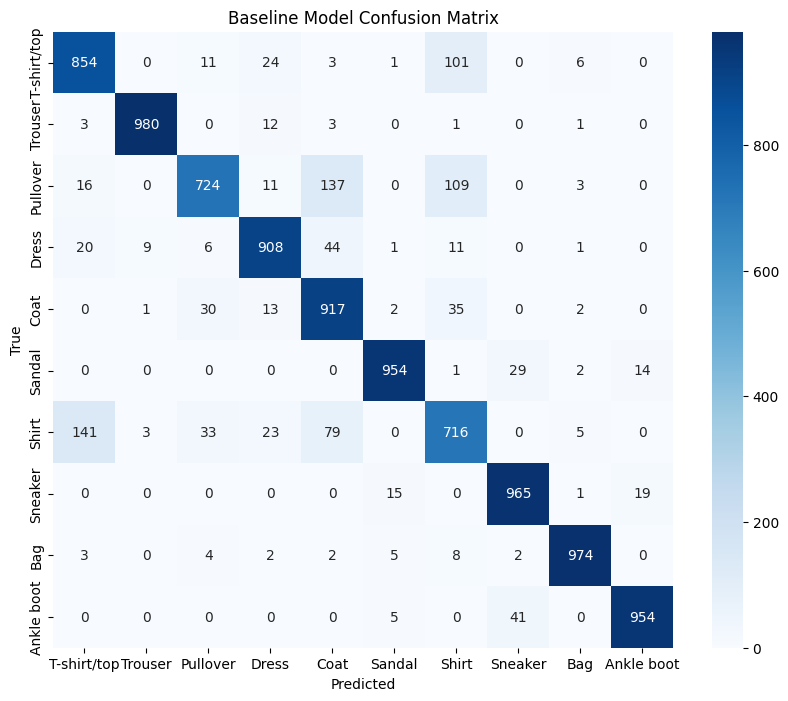

In [ ]:
y_pred_probs_baseline = baseline_model.predict(X_test_normalized)
y_pred_baseline = np.argmax(y_pred_probs_baseline, axis=1)
y_true = np.argmax(y_test_one_hot, axis=1)

accuracy_baseline = accuracy_score(y_true, y_pred_baseline)
print(f"\nBaseline Model Overall Accuracy: {accuracy_baseline * 100:.2f}%")

print("\nBaseline Model Classification Report:")
print(classification_report(y_true, y_pred_baseline, target_names=class_names))

cm_baseline = confusion_matrix(y_true, y_pred_baseline)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Baseline Model Confusion Matrix')
plt.show()

### 3. Hyperparameter Optimization

In [ ]:
keras_clf = KerasClassifier(
    model=create_model,
    n_hidden=1,
    n_neurons=64,
    activation='relu',
    dropout_rate=0.0,
    optimizer='adam',
    verbose=0
)

param_dist = {
    'model__n_hidden': [1, 2],
    'model__n_neurons': [64, 128],
    'model__activation': ['relu', 'tanh'],
    'optimizer': ['adam', 'rmsprop'],
    'batch_size': [32, 64],
    'epochs': [10]
}

random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_dist,
    n_iter=3,
    cv=2,
    verbose=1,
    error_score='raise'
)

print("Executing hyperparameter search...")
try:
    random_search_result = random_search.fit(X_train_normalized, y_train_one_hot)
    print(f"\nBest Score: {random_search_result.best_score_:.4f}")
    print(f"Best Params: {random_search_result.best_params_}")
except AttributeError as e:
    if 'sklearn_tags' in str(e):
        print("\nERROR: Library version conflict detected.")
        print("FIX: Please go to 'Runtime' -> 'Restart session', then run your cells from the top. This will apply the scikit-learn downgrade correctly.")
    else:
        raise e
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Executing hyperparameter search...
Fitting 2 folds for each of 3 candidates, totalling 6 fits


KeyboardInterrupt: 

### 4. Visualizing Model Training and Hyperparameter Search Results

/tmp/ipykernel_2537/2755343879.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis', legend=False)
/tmp/ipykernel_2537/2755343879.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, palette='viridis', legend=False)


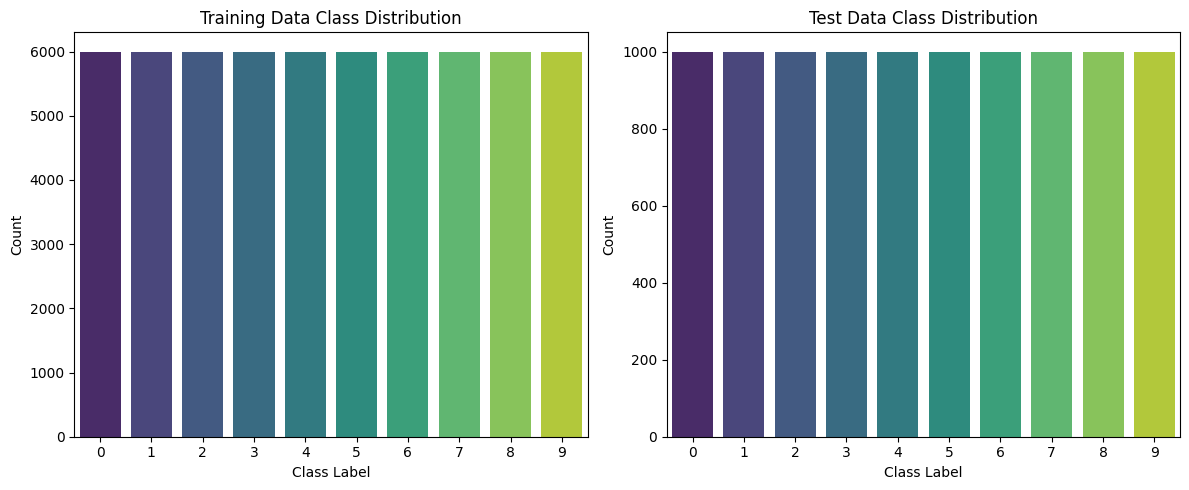

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis', legend=False)
plt.title('Training Data Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=y_test, palette='viridis', legend=False)
plt.title('Test Data Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

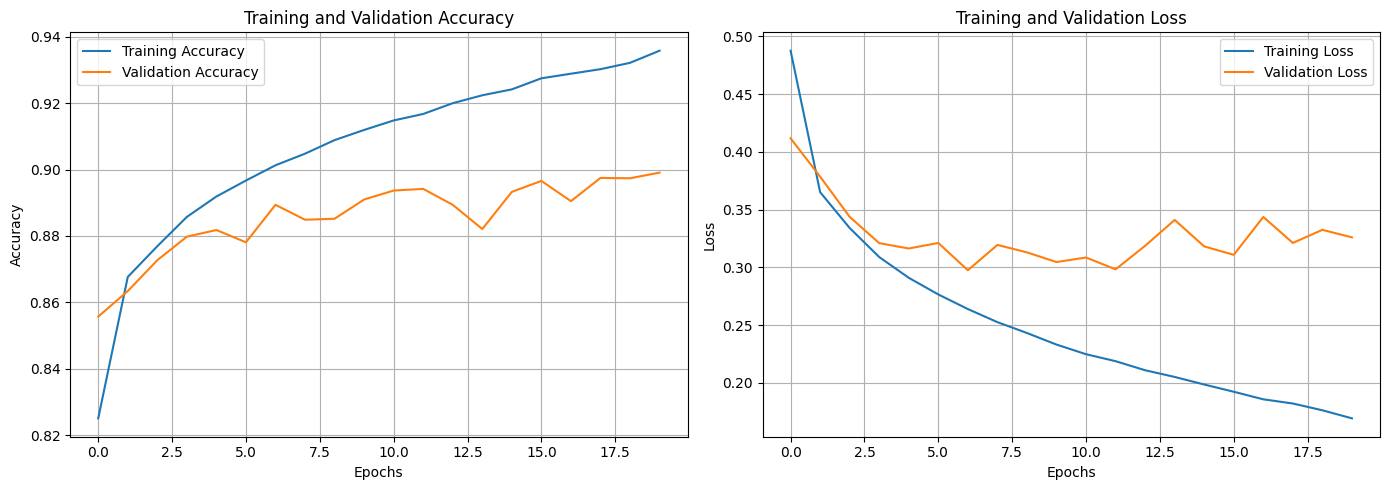

In [ ]:
history_dict = history.history

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2537/2002878306.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='mean_test_score', data=results_df, palette='viridis', legend=False)


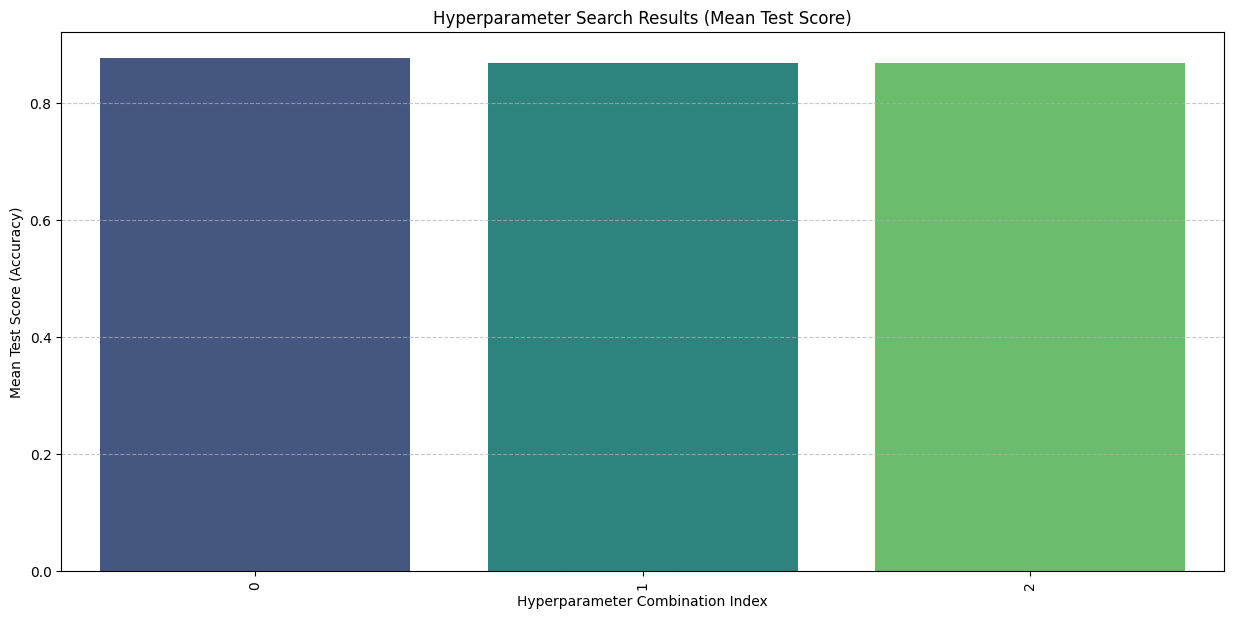

Top 3 Hyperparameter Combinations and their Scores:


,params,mean_test_score
0,"{'optimizer': 'rmsprop', 'model__n_neurons': 1...",0.877083
2,"{'optimizer': 'adam', 'model__n_neurons': 64, ...",0.867667
1,"{'optimizer': 'rmsprop', 'model__n_neurons': 6...",0.867650


In [ ]:
results_df = pd.DataFrame(random_search_result.cv_results_)

# Sort by mean_test_score for better visualization
results_df = results_df.sort_values(by='mean_test_score', ascending=False)

plt.figure(figsize=(15, 7))
sns.barplot(x=results_df.index, y='mean_test_score', data=results_df, palette='viridis', legend=False)
plt.xticks(rotation=90)
plt.title('Hyperparameter Search Results (Mean Test Score)')
plt.xlabel('Hyperparameter Combination Index')
plt.ylabel('Mean Test Score (Accuracy)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Top 3 Hyperparameter Combinations and their Scores:")
display(results_df[['params', 'mean_test_score']].head(3))

### 5. Retraining with Optimized Model and Comparison

In [ ]:
best_params = random_search_result.best_params_

optimized_model = create_model(
    n_hidden=best_params['model__n_hidden'],
    n_neurons=best_params['model__n_neurons'],
    activation=best_params['model__activation'],
    dropout_rate=0.0, # Dropout was not part of the search space, keeping default
    optimizer=best_params['optimizer']
)

print("Optimized model created and compiled with best parameters:")
optimized_model.summary()

history_optimized = optimized_model.fit(
    X_train_normalized,
    y_train_one_hot,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_data=(X_test_normalized, y_test_one_hot)
)

print("Optimized model training complete.")

Optimized model created and compiled with best parameters:


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8088 - loss: 0.5384 - val_accuracy: 0.8390 - val_loss: 0.4387
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8576 - loss: 0.3938 - val_accuracy: 0.8639 - val_loss: 0.3917
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8723 - loss: 0.3541 - val_accuracy: 0.8675 - val_loss: 0.3745
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8810 - loss: 0.3286 - val_accuracy: 0.8606 - val_loss: 0.3897
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8855 - loss: 0.3121 - val_accuracy: 0.8796 - val_loss: 0.3283
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8928 - loss: 0.2973 - val_accuracy: 0.8741 - val_loss: 0.3462
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8947 - loss: 0.2868 - val_accuracy: 0.8813 - val_loss: 0.3286
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9000 - loss: 0.2745 - val_accuracy: 0.

Optimized Model Test Accuracy: 88.82%
Optimized Model Test Loss: 0.3221

Baseline Model Test Accuracy (final epoch): 89.91%
Baseline Model Test Loss (final epoch): 0.3259


/tmp/ipykernel_2537/708829703.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='coolwarm')


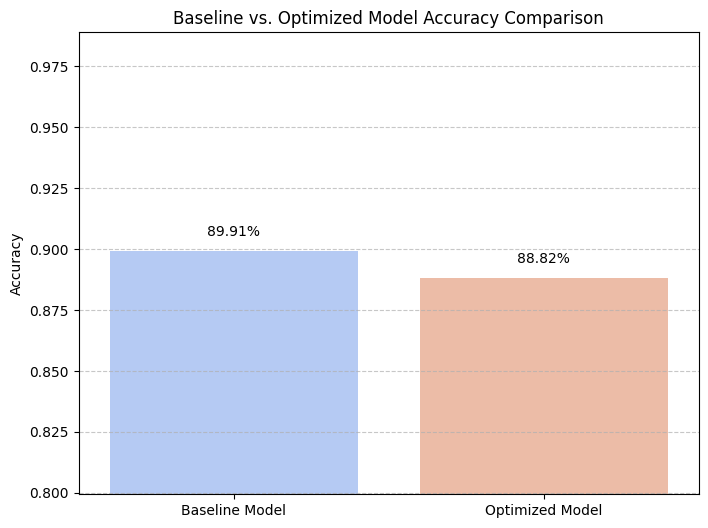

In [ ]:
loss_optimized, accuracy_optimized = optimized_model.evaluate(X_test_normalized, y_test_one_hot, verbose=0)
print(f"Optimized Model Test Accuracy: {accuracy_optimized * 100:.2f}%")
print(f"Optimized Model Test Loss: {loss_optimized:.4f}")

baseline_accuracy_final = history.history['val_accuracy'][-1]
baseline_loss_final = history.history['val_loss'][-1]
print(f"\nBaseline Model Test Accuracy (final epoch): {baseline_accuracy_final * 100:.2f}%")
print(f"Baseline Model Test Loss (final epoch): {baseline_loss_final:.4f}")

model_names = ['Baseline Model', 'Optimized Model']
accuracies = [baseline_accuracy_final, accuracy_optimized]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies, palette='coolwarm')
plt.title('Baseline vs. Optimized Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(min(accuracies) * 0.9, max(accuracies) * 1.1) # Adjust y-axis for better visibility
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.005, f'{value*100:.2f}%', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()